# calibra — quickstart

This notebook walks through the recommended usage of **calibra**: uncertainty quantification for language model outputs.

It covers:
1. Installation
2. Load a model
3. Single-prompt uncertainty estimation
4. Benchmarking on a custom dataset
5. Metrics and visualisation

## 1. Installation

In [1]:
%pip install git+https://github.com/tjoliveira/calibra.git

  Cloning https://github.com/tjoliveira/calibra.git to /private/var/folders/n0/ccmjs0ks4xx9lppm9k38_1dr0000gn/T/pip-req-build-27gxwj7w
  Running command git clone --filter=blob:none --quiet https://github.com/tjoliveira/calibra.git /private/var/folders/n0/ccmjs0ks4xx9lppm9k38_1dr0000gn/T/pip-req-build-27gxwj7w
  Resolved https://github.com/tjoliveira/calibra.git to commit 6026a3c5c84f2c469bd2eda3bf4fe4cfe27fdd92
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import llm_uq
print(llm_uq.__version__)

/Users/tiago/.pyenv/versions/cv-practice/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.1.0


## 2. Load a model

`Estimator.from_pretrained` accepts any HuggingFace causal LM.  
Use a small model here so the notebook runs on CPU in a reasonable time.  
On a GPU machine, swap in `Qwen/Qwen3-8B` (or larger) for better results.

In [3]:
from llm_uq import Estimator

# Small model — fast enough for a notebook demo
# Replace with e.g. "Qwen/Qwen3-8B" for production use
MODEL = "Qwen/Qwen3-0.6B"

est = Estimator.from_pretrained(
    MODEL,
    trust_remote_code=True,                 # required for some Qwen checkpoints
    semantic_model="all-MiniLM-L6-v2",      # needed for self_consistency / bsdetector
)

trust_remote_code=True: the model repo 'Qwen/Qwen3-0.6B' may execute arbitrary Python code on your machine. Only use this with repos you fully trust.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10693.40it/s]


## 3. Single-prompt uncertainty estimation

Call `est.estimate()` with any text prompt.  
Scores closer to **0 = confident**, higher = more uncertain.

**Probability-based** methods (`entropy`, `max_probability`, `sequence_probability`) need one forward pass.  
**Sampling-based** methods (`self_consistency`, `self_reflection`, `bsdetector`) need additional passes.

In [4]:
# Probability-based methods: one forward pass, very fast
scores = est.estimate(
    "What is the capital of France?",
    methods=["entropy", "max_probability", "sequence_probability"],
)
print(scores)

{'entropy': 1.1266149122441493, 'max_probability': 0.2900984466075897, 'sequence_probability': 0.4386265836746634}


In [5]:
# Sampling-based methods: multiple forward passes + semantic similarity
scores_all = est.estimate(
    "What is the capital of France?",
    methods=["entropy", "self_consistency", "self_reflection", "bsdetector"],
    num_samples=3,      # keep low for the demo
    max_new_tokens=50,
)
print(scores_all)

{'entropy': 1.029047697077258, 'self_consistency': 0.43021432558695477, 'self_reflection': 0.0, 'bsdetector': 0.3625104596217473}


In [6]:
# Compare a factual question vs. a speculative one
factual     = est.estimate("What is 2 + 2?",                   methods=["entropy"])
speculative = est.estimate("What will happen to AI in 2050?",  methods=["entropy"])

print(f"Factual    entropy: {factual['entropy']:.4f}")
print(f"Speculative entropy: {speculative['entropy']:.4f}")

Factual    entropy: 0.2952
Speculative entropy: 1.7578


### Token-level breakdown

`score_all()` returns token-level uncertainty for the probability-based methods.

In [7]:
detailed = est.score_all(
    "What is the tallest mountain on Earth?",
    max_new_tokens=30,
)

print("sentence entropy :", detailed["entropy"]["sentence"])
print("per-token entropy:", [f"{x:.3f}" for x in detailed["entropy"]["tokens"]])

self_reflection skipped: Could not parse self-reflection response (expected A/B/C, got: '</')
bsdetector: self_reflection failed — Could not parse self-reflection response (expected A/B/C, got: '</')


sentence entropy : 1.5681045403083165
per-token entropy: ['2.907', '1.391', '1.019', '3.047', '1.021', '1.397', '1.612', '1.085', '0.668', '0.116', '1.577', '0.903', '1.672', '2.067', '1.437', '1.326', '1.967', '0.624', '0.127', '1.709', '0.860', '1.425', '2.534', '2.870', '2.474', '3.058', '2.730', '1.237', '1.622', '0.558']


## 4. Benchmark on a custom dataset

Pass a list of `{"input": ..., "target": ...}` dicts to `bench.run()`.  
Results expose:
- `results.uncertainties` — per-method, per-sample scores  
- `results.errors` — per-sample error values  
- `results.auroc` / `results.ece` — aggregated metrics

In [8]:
from llm_uq import Benchmark

custom_data = [
    {"input": "Who wrote Hamlet?",                       "target": "Shakespeare"},
    {"input": "What year did World War II end?",         "target": "1945"},
    {"input": "What is the chemical formula of water?",  "target": "H2O"},
    {"input": "Who painted the Mona Lisa?",              "target": "Leonardo da Vinci"},
    {"input": "What is the speed of light in m/s?",      "target": "299792458"},
]

bench = Benchmark(est)
results = bench.run(
    task="qa",
    dataset=custom_data,
    methods=["entropy", "max_probability", "sequence_probability"],
    max_new_tokens=10,
)

print("AUROC:", results.auroc)
print("ECE  :", results.ece)

Benchmark [qa]: 100%|██████████| 5/5 [00:01<00:00,  3.54it/s]

AUROC: {'entropy': 1.0, 'max_probability': 1.0, 'sequence_probability': 1.0}
ECE  : {'entropy': 0.21411875170669756, 'max_probability': 0.18542104849679522, 'sequence_probability': 0.20617440295134665}


In [9]:
# Inspect per-sample scores
import pandas as pd

df = pd.DataFrame({
    "question": [d["input"] for d in custom_data],
    "error"   : results.errors,
    **{m: results.uncertainties[m] for m in results.uncertainties},
})
df

,question,error,entropy,max_probability,sequence_probability
0,Who wrote Hamlet?,1.0,1.707634,0.379914,0.541921
1,What year did World War II end?,0.0,0.160714,0.042288,0.046968
2,What is the chemical formula of water?,0.0,0.678524,0.163160,0.194186
3,Who painted the Mona Lisa?,1.0,1.968124,0.444365,0.726642
4,What is the speed of light in m/s?,1.0,0.811421,0.256921,0.357924


## 5. Metrics

The `calibra.metrics` module exposes each metric individually.

In [10]:
from llm_uq import metrics

u = results.uncertainties["entropy"]
e = results.errors

print("AUROC            :", metrics.auroc(u, e))
ece_score, _ = metrics.ece(u, e)
print("ECE              :", ece_score)
print("Correlations     :", metrics.correlations(u, e))
print("Uncertainty stats:", metrics.uncertainty_stats(u))

AUROC            : 1.0
ECE              : 0.21411875170669756
Correlations     : {'pearson': (0.7841355482606145, 0.11641739754157399), 'spearman': (0.8660254037844386, 0.05766888562243736)}
Uncertainty stats: {'mean': 1.0652833171499272, 'std': 0.6723109168627874, 'min': 0.16071386666347584, 'max': 1.9681235949198406, 'median': 0.8114213688919941, 'q25': 0.6785236874905726, 'q75': 1.7076340677837532}


In [11]:
# All metrics in one call
summary = metrics.summarize(u, e)
print(summary)

MetricSummary(auroc=1.0, ece=0.21411875170669756, pearson=nan, spearman=nan, error_rate=0.6, total_samples=5, uncertainty_stats={'mean': 1.0652833171499272, 'std': 0.6723109168627874, 'min': 0.16071386666347584, 'max': 1.9681235949198406, 'median': 0.8114213688919941, 'q25': 0.6785236874905726, 'q75': 1.7076340677837532})


## 6. Visualisation

`calibra.viz` provides ready-made plots that also accept a Matplotlib `ax=` argument for composability.

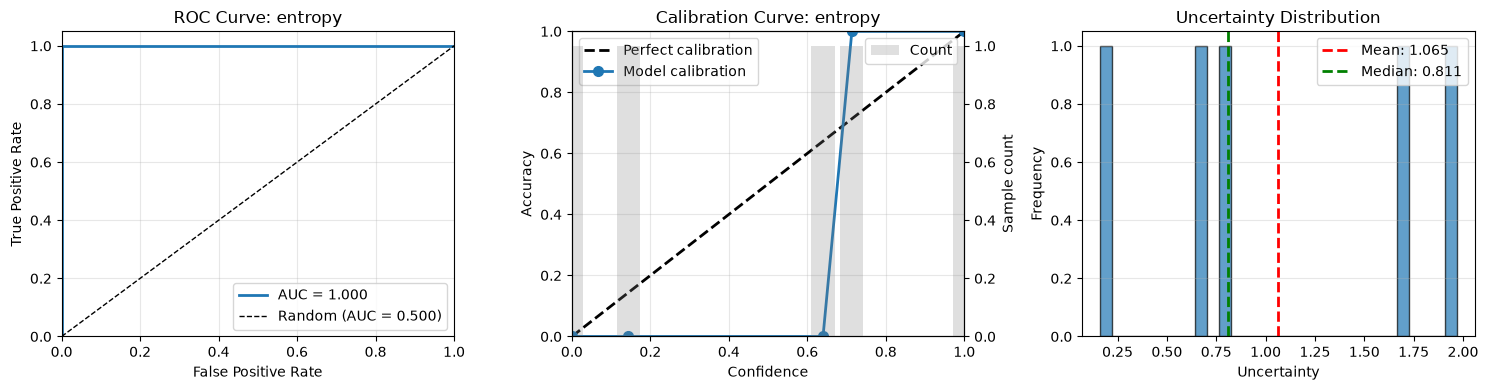

In [14]:
from llm_uq import viz
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

viz.roc_curve(
    results.uncertainties["entropy"],
    results.errors,
    method_name="entropy",
    ax=axes[0],
)

viz.calibration_curve(
    results.uncertainties["entropy"],
    results.errors,
    method_name="entropy",
    ax=axes[1],
)

viz.distribution(
    results.uncertainties["entropy"],
    ax=axes[2],
)

plt.tight_layout()
plt.show()

In [ ]:

results_squad = bench.run(
     task="qa",
     dataset="squad",
     methods=["entropy", "max_probability"],
     max_samples=50,
)
print(results_squad.auroc)